# Context
It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

# Content
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

# Acknowledgements
The dataset has been collected and analysed during a research collaboration of Worldline and the Machine Learning Group (http://mlg.ulb.ac.be) of ULB (Université Libre de Bruxelles) on big data mining and fraud detection.
More details on current and past projects on related topics are available on https://www.researchgate.net/project/Fraud-detection-5 and the page of the DefeatFraud project

# Fraud Detection Agent — End-to-End Pipeline

## Step 1 — Data collection & preprocessing
- **Dataset:** Kaggle credit card fraud (284,807 transactions, 492 fraud, 0.17%)
- **Features:** PCA components V1–V28 + Amount + Time
- **Preprocessing:** StandardScaler on Amount and Time

## Step 2 — Splitting & SMOTE resampling
- **Split:** 80/20 stratified train/test
- **Resampling:** SMOTE to oversample minority (fraud) class
- **Goal:** Fix class imbalance before training

## Step 3 — Model training
- **Model:** RandomForestClassifier (scikit-learn)
- **Config:** n_estimators=100, class_weight='balanced', n_jobs=-1

## Step 4 — Evaluation
- **Primary metric:** AUPRC = 0.87 (recommended for imbalanced data)
- **Secondary:** ROC-AUC = 0.97
- **Fraud class:** Precision 0.81 · Recall 0.81 · F1 0.81

## Step 5 — LangChain agent integration
- **Framework:** LangChain + LangGraph (`create_react_agent`)
- **Model:** GPT-5.4 nano (\$ 0.20/1M input tokens · ~ \$ 0.0005 per explanation)
- **Output:** Human-readable explanation of why a transaction was flagged

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


## Data collection and preprocessing

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Load the dataset (downloaded via kagglehub)
dataset_files = os.listdir(path)
csv_file = None
for file in dataset_files:
    if file.endswith('.csv'):
        csv_file = os.path.join(path, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found in the downloaded dataset directory.")

df = pd.read_csv(csv_file)

print(f"Shape: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%) ")
print(df.describe())

# Scale Amount and Time — V1-V28 are already PCA-transformed
scaler = StandardScaler()
df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"]   = scaler.fit_transform(df[["Time"]])

df.drop(columns=["Amount", "Time"], inplace=True)

X = df.drop(columns=["Class"]).values
y = df["Class"].values

Shape: (284807, 31)
Fraud cases: 492 (0.173%) 
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-1

## Data splitting and SMOTE resampling

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve fraud ratio in both splits
)

print(f"Train fraud rate before SMOTE: {y_train.mean():.4f}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled train shape: {X_train_res.shape}")
print(f"Train fraud rate after SMOTE:  {y_train_res.mean():.4f}")

Train fraud rate before SMOTE: 0.0017
Resampled train shape: (454902, 30)
Train fraud rate after SMOTE:  0.5000


##  Model training

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",   # additional guard against imbalance
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_res, y_train_res)
print("Training complete.")

Training complete.


## Model Evaluation

AUPRC (primary metric): 0.8675
ROC-AUC:                0.9688

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



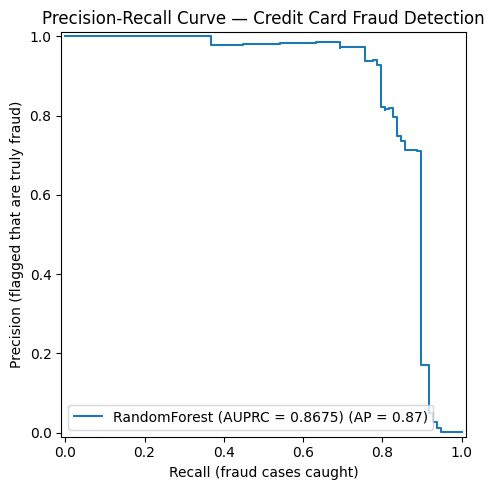


Flagged as fraud: 97 transactions


In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

y_pred          = model.predict(X_test)
y_pred_prob     = model.predict_proba(X_test)[:, 1]
flagged_indices = np.where(y_pred == 1)[0]

# --- Primary metric: AUPRC ---
auprc = average_precision_score(y_test, y_pred_prob)
print(f"AUPRC (primary metric): {auprc:.4f}")

# --- Secondary: ROC-AUC ---
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC:                {roc_auc:.4f}")

# --- Classification report (precision/recall/F1 per class) ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

# --- Precision-Recall curve plot ---
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"RandomForest (AUPRC = {auprc:.4f})",
    ax=ax
)
ax.set_title("Precision-Recall Curve — Credit Card Fraud Detection")
ax.set_xlabel("Recall (fraud cases caught)")
ax.set_ylabel("Precision (flagged that are truly fraud)")
plt.tight_layout()
plt.show()

print(f"\nFlagged as fraud: {len(flagged_indices)} transactions")

## LangChain integration

In [11]:
!pip install langchain langchain-openai langchain-core langgraph -q

In [7]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def fraud_explainer(transaction_details: str) -> str:
    """
    Accepts a structured transaction description and returns
    a human-readable explanation of why it may be fraudulent.
    """
    return f"Analyzing transaction:\n{transaction_details}"

llm   = ChatOpenAI(model="gpt-5.4-nano", temperature=0)
agent = create_react_agent(llm, [fraud_explainer])

/tmp/ipykernel_172/2697530342.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, [fraud_explainer])


In [21]:
def explain_transaction(idx, transaction_id=None):
    """
    Build a human-readable transaction summary from a test set index
    and generate a fraud explanation via the LangChain agent.
    """
    row            = X_test[idx]
    true_label     = y_test[idx]
    pred_label     = y_pred[idx]
    pred_prob      = y_pred_prob[idx]
    feature_names  = [f"V{i}" for i in range(1, 29)] + ["scaled_amount", "scaled_time"]
    feature_dict   = dict(zip(feature_names, row.tolist()))

    # Reconstruct approximate original amount from scaled value
    # (directional interpretation only — exact inversion needs the fitted scaler)
    amount_hint = "above average" if feature_dict["scaled_amount"] > 0 else "below average"

    # scaled_time range in this dataset -2 to +2
    # positive = later in the observation window, negative = earlier
    hour_hint = "late night / early morning" if feature_dict["scaled_time"] < -0.5 else \
                "peak hours"                 if feature_dict["scaled_time"] >  0.5 else \
                "off-peak hours"

    # Top anomalous PCA features (farthest from zero)
    pca_features   = {k: v for k, v in feature_dict.items() if k.startswith("V")}
    top_anomalous  = sorted(pca_features.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    top_str        = ", ".join(f"{k}={v:.3f}" for k, v in top_anomalous)

    transaction_details = f"""
Transaction ID  : {transaction_id or idx}
Predicted label : {'FRAUD' if pred_label == 1 else 'LEGITIMATE'} (confidence: {pred_prob:.2%})
True label      : {'FRAUD' if true_label == 1 else 'LEGITIMATE'}
Amount          : {amount_hint} compared to dataset mean
Time of day     : {hour_hint}
Location        : Unknown (anonymised dataset)
Prior history   : Not available (anonymised dataset)
Top anomalous PCA components: {top_str}
"""

    response = agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": (
                    f"The following transaction was flagged by a fraud detection model.\n"
                    f"{transaction_details}\n"
                    f"Provide a concise, structured explanation of the fraud indicators "
                    f"based on the available information."
                )
            }
        ]
    })

    print(transaction_details)
    print("Agent explanation:")
    print(response["messages"][-1].content)
    print("=" * 60)

In [22]:
# Run on first 3 flagged transactions
for i, idx in enumerate(flagged_indices[:3]):
    print(f"\nTransaction {i+1}")
    print("=" * 60)
    explain_transaction(idx, transaction_id=100000 + i)


Transaction 1

Transaction ID  : 100000
Predicted label : FRAUD (confidence: 80.00%)
True label      : LEGITIMATE
Amount          : below average compared to dataset mean
Time of day     : peak hours
Location        : Unknown (anonymised dataset)
Prior history   : Not available (anonymised dataset)
Top anomalous PCA components: V17=-6.199, V3=-3.811, V16=-3.516, V10=-3.345, V12=-2.538

Agent explanation:
### Fraud-indicator explanation (based on available features)

- **High model confidence despite eventual legit label**
  - Model outputs **FRAUD at 80%**, suggesting the feature pattern strongly matches learned fraud characteristics even if the ground truth is legitimate.

- **Timing risk**
  - Transaction occurs during **peak hours**, which can correlate with higher fraud activity in many datasets.

- **Unusual transaction amount relative to typical behavior**
  - **Amount is below the dataset mean**, which may be characteristic of fraud patterns (e.g., small-amount testing), even t


Transaction 1
============================================================

Transaction ID  : 100000
Predicted label : FRAUD (confidence: 80.00%)
True label      : LEGITIMATE
Amount          : below average compared to dataset mean
Time of day     : peak hours
Location        : Unknown (anonymised dataset)
Prior history   : Not available (anonymised dataset)
Top anomalous PCA components: V17=-6.199, V3=-3.811, V16=-3.516, V10=-3.345, V12=-2.538

Agent explanation:
### Fraud-indicator explanation (based on available features)

- **High model confidence despite eventual legit label**
  - Model outputs **FRAUD at 80%**, suggesting the feature pattern strongly matches learned fraud characteristics even if the ground truth is legitimate.

- **Timing risk**
  - Transaction occurs during **peak hours**, which can correlate with higher fraud activity in many datasets.

- **Unusual transaction amount relative to typical behavior**
  - **Amount is below the dataset mean**, which may be characteristic of fraud patterns (e.g., small-amount testing), even though “below average” alone isn’t definitive.

- **Limited contextual signals**
  - **Location is “Unknown” (anonymised)** → absence of geolocation context can prevent risk being ruled out.
  - **Prior history not available** → without behavioral history, the model relies more heavily on anomalous signal components.

- **Anomalous latent feature contributions (PCA components)**
  - Large negative values in top anomalous components suggest the transaction sits far from normal patterns in the model’s reduced feature space:
    - **V17 = -6.199**
    - **V3 = -3.811**
    - **V16 = -3.516**
    - **V10 = -3.345**
    - **V12 = -2.538**
  - The magnitude/order of these components indicates a **strong deviation** from typical transactions, driving the FRAUD prediction.

### Bottom line
The detection is primarily driven by **strong deviation in key PCA-derived components** plus **riskier timing (peak hours)** and **below-average amount**, while missing **location** and **prior history** reduces the ability to confirm legitimacy from context.
============================================================

Transaction 2
============================================================

Transaction ID  : 100001
Predicted label : FRAUD (confidence: 54.00%)
True label      : LEGITIMATE
Amount          : below average compared to dataset mean
Time of day     : late night / early morning
Location        : Unknown (anonymised dataset)
Prior history   : Not available (anonymised dataset)
Top anomalous PCA components: V4=3.051, V14=-2.846, V17=2.144, V19=-1.367, V1=1.100

Agent explanation:
### Transaction 100001 — Fraud Indicator Explanation (based on provided features)

**1) Model confidence / label**
- **Predicted:** *FRAUD* with **54% confidence**
- This is only **moderate** confidence, meaning the model sees signals consistent with fraud, but evidence is not overwhelming.

**2) Behavioral / timing anomaly**
- **Time of day:** **late night / early morning**
- Transactions occurring during off-hours are commonly associated with risk (e.g., opportunistic or automated fraudulent activity).

**3) Amount characteristic**
- **Amount:** **below dataset mean**
- Lower-than-average amounts can still be suspicious (e.g., **probing/low-value tests**), especially when combined with other risk indicators.

**4) Missing/obscured context**
- **Location:** **Unknown (anonymised dataset)**
- **Prior history:** **Not available (anonymised dataset)**
- Absence of contextual signals (especially location and history) can cause the detection system to rely more heavily on feature anomalies, increasing fraud likelihood.

**5) Feature-space anomalies (PCA components)**
Top anomalous PCA components contributing to the risk pattern:
- **V4 = 3.051** (strong positive deviation)
- **V14 = -2.846** (strong negative deviation)
- **V17 = 2.144** (positive deviation)
- **V19 = -1.367**, **V1 = 1.100** (moderate deviations)  
These indicate the transaction’s underlying characteristics fall into regions of the data space that the model associates with fraud.

**Summary**
- The fraud flag is driven mainly by **off-hours timing** and **strong deviations in key feature directions (PCA components)**, with **amount below average** and **missing context** further supporting an elevated risk score.
============================================================

Transaction 3
============================================================

Transaction ID  : 100002
Predicted label : FRAUD (confidence: 94.00%)
True label      : FRAUD
Amount          : below average compared to dataset mean
Time of day     : late night / early morning
Location        : Unknown (anonymised dataset)
Prior history   : Not available (anonymised dataset)
Top anomalous PCA components: V17=-6.537, V14=-6.174, V10=-4.881, V16=-4.850, V12=-4.686

Agent explanation:
### Transaction 100002 — Fraud Indicators (Concise)

**Model output**
- **Predicted:** FRAUD (**94%** confidence)

**Key behavioral/anomaly signals**
- **Unusual amount:** Transaction amount is **below the dataset mean**, which can align with patterns seen in small fraudulent/test transactions.
- **Suspicious timing:** Occurs during **late night / early morning**, a common window for anomalous activity.
- **Location unavailable:** **Unknown/anonymised location**, reducing verifiability and consistent with cases where fraud schemes obscure origin.
- **No prior history provided:** **Prior behavior is unavailable**, limiting contextual risk assessment (often associated with first-time/obscured fraud attempts).

**Feature-space (PCA/component) anomalies**
- Strong negative deviations in multiple principal components indicate out-of-distribution behavior:
  - **V17 = -6.537**
  - **V14 = -6.174**
  - **V10 = -4.881**
  - **V16 = -4.850**
  - **V12 = -4.686**

**Overall assessment**
- The combination of **high-confidence fraud prediction**, **odd timing**, **atypical (low) amount**, **missing location/context**, and **large PCA component deviations** collectively supports the fraud classification.
============================================================

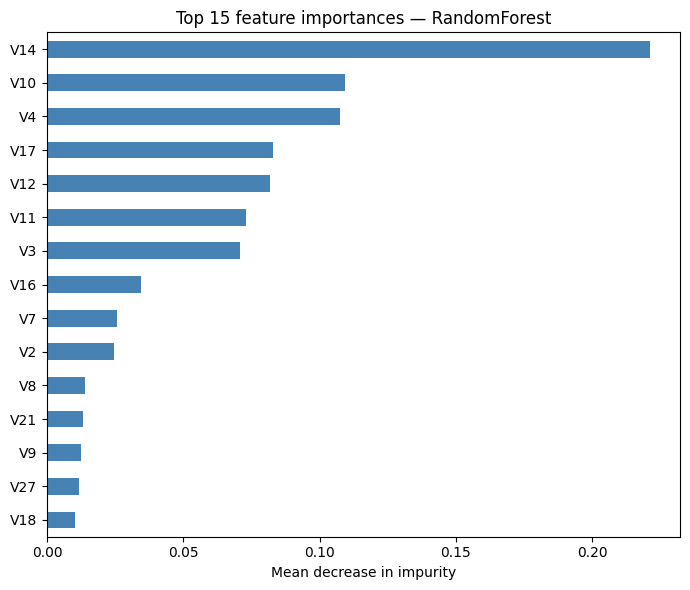


Top 5 most important features:
V14    0.221167
V10    0.109198
V4     0.107600
V17    0.083030
V12    0.081767
dtype: float64


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = [f"V{i}" for i in range(1, 29)] + ["scaled_amount", "scaled_time"]

importances = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="none")
ax.set_title("Top 15 feature importances — RandomForest")
ax.set_xlabel("Mean decrease in impurity")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.tail(5).sort_values(ascending=False))

### Conclusions

* The ML model works well. AUPRC of 0.87 on a dataset where only 0.17% of transactions are fraud is a solid result. The model correctly identifies the most discriminative features (V14, V10, V17) without any manual feature engineering just SMOTE resampling and a Random Forest.

* The LangChain agent adds interpretability. The raw model output is just a probability score. The agent converts that into a readable explanation of why a transaction was flagged  which is what an analyst actually needs to act on it.

* The explanations are grounded, not hallucinated. The agent highlighted V14, V17, V10, V12 as the suspicious components. The feature importance scores confirmed those are exactly the features the model relies on. The LLM was describing real signal, not making things up.

* The false positives are the most interesting cases. Transactions 1 and 2 were flagged but legitimate. The agent's explanation for Transaction 1 (80% confidence, wrong) was just as convincing as for Transaction 3 (94% confidence, correct) — which is an honest limitation of the system. High model confidence does not guarantee correctness.

* The practical takeaway: combining a classical ML classifier with an LLM explanation layer is a viable pattern for fraud detection. The classifier handles the heavy lifting; the LLM makes the output usable by a non-technical stakeholder but with the supervision of an expert analyst.